# Policy Gradient Methods: REINFORCE and Actor-Critic

## Lab Objectives

In this lab, you will:
1. **Implement REINFORCE algorithm** - Monte Carlo policy gradient
2. **Implement Actor-Critic algorithm** - Hybrid policy gradient with value function
3. **Compare three methods** on **two environments**:
   - Your best **Double-DQN** from previous lab
   - **REINFORCE** (this lab)
   - **Actor-Critic** (this lab)
4. **Analyze results** on:
   - **CartPole-v1** (familiar environment)
   - **Acrobot-v1** (new challenging environment)

## What You'll Learn

- Direct policy optimization vs value-based methods
- The high variance problem in policy gradients
- How Actor-Critic reduces variance
- Comparative analysis of different RL algorithms

## Theoretical Background

### 1. Policy Gradient Theorem

**Objective**: Maximize expected cumulative reward

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[G_t] = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \gamma^t r_t\right]$$

where $\tau = (s_0, a_0, r_0, s_1, \ldots)$ is a trajectory sampled from policy $\pi_\theta$.

**The Policy Gradient Theorem** provides a way to optimize policies directly:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

**Key Insight**: We can estimate the gradient using samples!

1. Collect trajectories by running $\pi_\theta$ in environment
2. Compute returns $G_t$ for each timestep
3. Compute gradient: $\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Update: $\theta \leftarrow \theta + \alpha \nabla_\theta J(\theta)$

### 2. REINFORCE Algorithm

**REINFORCE** implements the policy gradient theorem directly:

1. Generate episode: $s_0, a_0, r_0, \ldots, s_T, a_T, r_T$
2. For each timestep $t$:
   - Compute return: $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$
3. Compute loss: $L = -\sum_t \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Backpropagate: $\theta \leftarrow \theta + \alpha \nabla_\theta L$

**Problem**: High variance! $G_t$ varies a lot between trajectories.

### 3. Actor-Critic: Reducing Variance

**The High Variance Problem**: REINFORCE uses Monte Carlo returns $G_t$:
- Must wait until episode ends
- $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
- High variance: small changes in actions cause big changes in $G_t$

**Solution: Use a Value Function (Critic)**

Instead of full return $G_t$, use TD learning:
- Critic estimates $V(s; w)$
- TD error: $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$
- Use $\delta_t$ as \"advantage estimate\" for actor update

**Actor-Critic Architecture**:

1. **Actor**: Policy network $\pi(a|s; \theta)$ - selects actions
2. **Critic**: Value network $V(s; w)$ - estimates state value

**Update Rules**:

Critic: $w \leftarrow w - \alpha_w \cdot \nabla_w [\delta_t^2]$ where $\delta_t = r_t + \gamma V(s_{t+1}; w) - V(s_t; w)$

Actor: $\theta \leftarrow \theta + \alpha_\theta \cdot \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \delta_t$

**Why It Works**:
- Lower variance: $\delta_t$ is single-step TD error, not full return
- Faster learning: Update after every step
- Bias-variance trade-off favors Actor-Critic in practice

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from typing import Tuple, List

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

np.bool8 = np.bool

## Networks

We provide the neural network architectures. Your focus will be on implementing the training algorithms.

### Policy Network (Actor)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: action probabilities (softmax)

### Value Network (Critic)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: scalar value estimate

In [20]:
class PolicyNetwork(nn.Module):
    """Policy Network (Actor) that outputs action probabilities."""
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)
        return x


class ValueNetwork(nn.Module):
    """Value Network (Critic) that estimates state value V(s)."""
    
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Helper Functions

In [21]:
def select_action(policy: nn.Module, state: np.ndarray, device: str = 'cpu') -> Tuple[int, Tensor]:
    """
    Sample action from policy distribution.
    
    Args:
        policy: Policy network
        state: Current state
        device: Device to run on
        
    Returns:
        action: Sampled action (integer)
        log_prob: Log probability of the action
    """
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs = policy(state_tensor)
    
    # Create categorical distribution and sample
    action_dist = torch.distributions.Categorical(probs)
    action = action_dist.sample()
    log_prob = action_dist.log_prob(action)
    
    return action.item(), log_prob


def compute_returns(rewards: List[float], gamma: float = 0.99) -> Tensor:
    """
    Compute discounted returns for each timestep.
    
    Args:
        rewards: List of rewards from an episode
        gamma: Discount factor
        
    Returns:
        returns: Tensor of discounted returns
    """
    returns = []
    G = 0
    
    # Compute returns backwards from the end
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    return torch.FloatTensor(returns)

## Task 1: REINFORCE Training Loop

Implement the REINFORCE algorithm.

**Algorithm**:
1. Collect a full trajectory (episode)
2. Compute returns G_t for each timestep using `compute_returns()`
3. Normalize returns for variance reduction
4. Compute loss: -Σ log π(a_t|s_t) * G_t
5. Backpropagate and update policy

**Important**:
- Returns should be normalized: `(returns - returns.mean()) / (returns.std() + 1e-8)`
- Loss is negative because we want to maximize, not minimize
- The episode collection loop is provided; focus on the update section

In [22]:
def train_reinforce(
    env: gym.Env,
    policy: nn.Module,
    num_episodes: int = 1000,
    lr: float = 0.01,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using REINFORCE algorithm.
    
    Args:
        env: Gymnasium environment
        policy: Policy network
        num_episodes: Number of training episodes
        lr: Learning rate
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    episode_rewards = []
    
    for episode in range(num_episodes):
        # Storage for episode data
        log_probs = []
        rewards = []
        
        # Collect trajectory
        state, _ = env.reset()
        done = False
        
        while not done:
            action, log_prob = select_action(policy, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            rewards.append(reward)
            
            state = next_state
        
        # TODO: Task 1 - Implement REINFORCE update
        
        # Step 1: Compute returns using the compute_returns function

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        
        # Step 2: Normalize returns for variance reduction
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Step 3: Compute policy loss
        # FORMULA: L = -Σ log π(a_t|s_t) * G_t
        policy_loss = 0
        for log_prob, G in zip(log_probs, returns):
            policy_loss += -log_prob * G
                
        # Step 4: Backpropagate and update
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        # END TODO
        
        # Store episode reward
        episode_rewards.append(sum(rewards))
        
        # Logging
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")
    
    return episode_rewards

## Task 2: Actor-Critic Training Loop

Implement the Actor-Critic algorithm.

**Algorithm (per step)**:
1. Select action from actor policy
2. Observe reward and next state
3. Compute TD error: δ = r + γV(s') - V(s)
4. Update critic to minimize δ²
5. Update actor using: log π(a|s) * δ (detached)

**Important**:
- If episode is done, next_value = 0 (no future reward)
- TD error should be detached when used for actor update
- The step loop is provided; focus on the update section

In [23]:
def train_actor_critic(
    env: gym.Env,
    actor: nn.Module,
    critic: nn.Module,
    num_episodes: int = 1000,
    lr_actor: float = 0.001,
    lr_critic: float = 0.005,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using Actor-Critic algorithm.
    
    Args:
        env: Gymnasium environment
        actor: Policy network
        critic: Value network
        num_episodes: Number of training episodes
        lr_actor: Learning rate for actor
        lr_critic: Learning rate for critic
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)
    episode_rewards = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            # Select action using actor
            action, log_prob = select_action(actor, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            
            # TODO: Task 2 - Implement Actor-Critic updates
            
            # Step 1: Prepare state tensors for networks
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            
            # Step 2: Compute value estimates using critic
            V_s = critic(state_tensor)
            V_next = critic(next_state_tensor).detach()
            if terminated: 
                V_next = torch.tensor([[0.0]]).to(device)
                        
            # Step 3: Compute TD error (advantage estimate)
            # FORMULA: δ = r + γV(s') - V(s)
            delta = reward + gamma * V_next - V_s
            
            # Step 4: Update critic to minimize TD error squared
            critic_loss = F.mse_loss(V_s, reward + gamma * V_next)
            
            # Step 5: Update actor using policy gradient
            # CRITICAL: Use .detach() on td_error!
            
            actor_loss = -log_prob * delta.detach()
            # END TODO

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()
            
            state = next_state
        
        # Store episode reward
        episode_rewards.append(episode_reward)
        
        # Logging
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")
    
    return episode_rewards

## Task 3: CartPole Experiments

**Objective**: Compare three methods on CartPole-v1:
1. Your best Double-DQN from previous lab
2. REINFORCE (train here)
3. Actor-Critic (train here)

**Instructions**:
1. Load your best DDQN results (episode rewards)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- Which method converges fastest?
- Which has lowest variance?
- Which achieves best final performance?

In [24]:
# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create CartPole environment
env_cartpole = gym.make('CartPole-v1', max_episode_steps=200)
state_dim = env_cartpole.observation_space.shape[0]
action_dim = env_cartpole.action_space.n
print(f"CartPole - State dim: {state_dim}, Action dim: {action_dim}")

Using device: cuda
CartPole - State dim: 4, Action dim: 2


In [25]:
# TODO: Task 3 - CartPole Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_cartpole.reset()

# Part 1: Load your best Double-DQN results
# Replace this with your actual DDQN results from previous lab
# ddqn_rewards = np.load('path_to_your_ddqn_results.npy').tolist()
# OR manually copy the list of rewards

# For now, we'll use a placeholder
ddqn_rewards = None  # Replace with your DDQN results

# Part 2: Train REINFORCE on CartPole
print("\n" + "="*50)
print("Training REINFORCE on CartPole...")
print("="*50)

reinforce_policy_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
reinforce_rewards_cartpole = train_reinforce(
    env=env_cartpole,
    policy=reinforce_policy_cartpole,
    num_episodes=1000,
    lr=0.01,
    gamma=0.99,
    device=device
)

# Part 3: Train Actor-Critic on CartPole
print("\n" + "="*50)
print("Training Actor-Critic on CartPole...")
print("="*50)

actor_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
critic_cartpole = ValueNetwork(state_dim).to(device)
ac_rewards_cartpole = train_actor_critic(
    env=env_cartpole,
    actor=actor_cartpole,
    critic=critic_cartpole,
    num_episodes=1000,
    lr_actor=0.001,
    lr_critic=0.005,
    gamma=0.99,
    device=device
)

print("\nCartPole training complete!")


Training REINFORCE on CartPole...
Episode    0 | Avg Reward:  12.00
Episode   50 | Avg Reward:  41.22
Episode  100 | Avg Reward: 144.86
Episode  150 | Avg Reward: 188.68
Episode  200 | Avg Reward:  55.28
Episode  250 | Avg Reward:  98.62
Episode  300 | Avg Reward: 176.66
Episode  350 | Avg Reward: 187.96
Episode  400 | Avg Reward: 200.00
Episode  450 | Avg Reward: 200.00
Episode  500 | Avg Reward: 163.06
Episode  550 | Avg Reward:  90.02
Episode  600 | Avg Reward: 158.86
Episode  650 | Avg Reward: 183.54
Episode  700 | Avg Reward: 146.70
Episode  750 | Avg Reward: 181.48
Episode  800 | Avg Reward: 200.00
Episode  850 | Avg Reward: 175.20
Episode  900 | Avg Reward: 177.36
Episode  950 | Avg Reward: 200.00

Training Actor-Critic on CartPole...
Episode    0 | Avg Reward:  19.00
Episode   50 | Avg Reward:  11.58
Episode  100 | Avg Reward:  42.44
Episode  150 | Avg Reward:  69.22
Episode  200 | Avg Reward: 115.40
Episode  250 | Avg Reward: 130.86
Episode  300 | Avg Reward: 175.48
Episode  

## Task 4: Acrobot Experiments

**Objective**: Compare three methods on Acrobot-v1:

**About Acrobot**:
- Two-link pendulum robot
- Goal: Swing up to reach target height
- State: 6 dimensions (angles, velocities)
- Actions: 3 (torque left, none, right)
- Reward: -1 per step until goal reached
- More challenging than CartPole!

**Instructions**:
1. Load your best DDQN results on Acrobot (or train new DDQN)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- How do results compare to CartPole?
- Which method handles this harder environment best?
- Is Actor-Critic's advantage more pronounced here?

In [16]:
# Create Acrobot environment
env_acrobot = gym.make('Acrobot-v1', max_episode_steps=500)
state_dim_acrobot = env_acrobot.observation_space.shape[0]  # 6
action_dim_acrobot = env_acrobot.action_space.n  # 3
print(f"Acrobot - State dim: {state_dim_acrobot}, Action dim: {action_dim_acrobot}")
print(f"Max episode steps: 500")

Acrobot - State dim: 6, Action dim: 3
Max episode steps: 500


In [29]:
# TODO: Task 4 - Acrobot Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_acrobot.reset()

# Part 1: Load your best Double-DQN results on Acrobot
# ddqn_rewards_acrobot = None  # Replace with your DDQN results

# Part 2: Train REINFORCE on Acrobot
print("\n" + "="*50)
print("Training REINFORCE on Acrobot...")
print("="*50)

reinforce_policy_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
reinforce_rewards_acrobot = train_reinforce(
    env=env_acrobot,
    policy=reinforce_policy_acrobot,
    num_episodes=1000,
    lr=0.01,
    gamma=0.99,
    device=device
)

# Part 3: Train Actor-Critic on Acrobot
print("\n" + "="*50)
print("Training Actor-Critic on Acrobot...")
print("="*50)

actor_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
critic_acrobot = ValueNetwork(state_dim_acrobot).to(device)
ac_rewards_acrobot = train_actor_critic(
    env=env_acrobot,
    actor=actor_acrobot,
    critic=critic_acrobot,
    num_episodes=1000,
    lr_actor=0.001,
    lr_critic=0.005,
    gamma=0.99,
    device=device
)

print("\nAcrobot training complete!")


Training REINFORCE on Acrobot...
Episode    0 | Avg Reward: -500.00
Episode   50 | Avg Reward: -187.60
Episode  100 | Avg Reward: -193.44
Episode  150 | Avg Reward: -345.84
Episode  200 | Avg Reward: -213.84
Episode  250 | Avg Reward: -96.62
Episode  300 | Avg Reward: -91.70
Episode  350 | Avg Reward: -90.52
Episode  400 | Avg Reward: -204.96
Episode  450 | Avg Reward: -500.00
Episode  500 | Avg Reward: -500.00
Episode  550 | Avg Reward: -500.00
Episode  600 | Avg Reward: -500.00
Episode  650 | Avg Reward: -500.00
Episode  700 | Avg Reward: -500.00
Episode  750 | Avg Reward: -500.00
Episode  800 | Avg Reward: -500.00
Episode  850 | Avg Reward: -500.00
Episode  900 | Avg Reward: -500.00
Episode  950 | Avg Reward: -500.00

Training Actor-Critic on Acrobot...
Episode    0 | Avg Reward: -221.00
Episode   50 | Avg Reward: -113.30
Episode  100 | Avg Reward: -89.80
Episode  150 | Avg Reward: -90.74
Episode  200 | Avg Reward: -86.02
Episode  250 | Avg Reward: -87.48
Episode  300 | Avg Reward:

## Visualization Functions

In [4]:
def moving_average_with_variance(data: List[float], window_size: int = 50) -> Tuple:
    """
    Calculate moving average and variance.
    
    Returns:
        indices, means, [lower_bounds, upper_bounds]
    """
    if len(data) < window_size:
        return [], [], []
    
    indices = np.arange(window_size - 1, len(data))
    means = []
    upper_bounds = []
    lower_bounds = []
    
    for i in range(window_size - 1, len(data)):
        window = data[i - window_size + 1 : i + 1]
        mean_val = np.mean(window)
        std_val = np.std(window)
        means.append(mean_val)
        upper_bounds.append(mean_val + std_val)
        lower_bounds.append(mean_val - std_val)
    
    return indices, means, [lower_bounds, upper_bounds]


def plot_comparison(ddqn_rewards, reinforce_rewards, ac_rewards, env_name: str):
    """Plot comparison of three methods."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot DDQN if available
    if ddqn_rewards is not None:
        x_dqn, dqn_mean, dqn_var = moving_average_with_variance(ddqn_rewards, 50)
        ax.plot(x_dqn, dqn_mean, color='green', label='Double-DQN', alpha=0.8, linewidth=2)
        ax.fill_between(x_dqn, dqn_var[0], dqn_var[1], alpha=0.2, color='green')
    
    # Plot REINFORCE
    x_rf, rf_mean, rf_var = moving_average_with_variance(reinforce_rewards, 50)
    ax.plot(x_rf, rf_mean, color='blue', label='REINFORCE', alpha=0.8, linewidth=2)
    ax.fill_between(x_rf, rf_var[0], rf_var[1], alpha=0.2, color='blue')
    
    # Plot Actor-Critic
    x_ac, ac_mean, ac_var = moving_average_with_variance(ac_rewards, 50)
    ax.plot(x_ac, ac_mean, color='orange', label='Actor-Critic', alpha=0.8, linewidth=2)
    ax.fill_between(x_ac, ac_var[0], ac_var[1], alpha=0.2, color='orange')
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Average Reward (50-episode window)', fontsize=12)
    ax.set_title(f'Algorithm Comparison on {env_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFinal Performance on {env_name} (last 100 episodes):")
    if ddqn_rewards is not None:
        print(f"Double-DQN:   {np.mean(ddqn_rewards[-100:]):7.2f} +/- {np.std(ddqn_rewards[-100:]):.2f}")
    print(f"REINFORCE:    {np.mean(reinforce_rewards[-100:]):7.2f} +/- {np.std(reinforce_rewards[-100:]):.2f}")
    print(f"Actor-Critic: {np.mean(ac_rewards[-100:]):7.2f} +/- {np.std(ac_rewards[-100:]):.2f}")

## Results: CartPole Comparison

In [27]:
ddqn_rewards_cartpole = [34.0, 19.0, 16.0, 31.0, 18.0, 28.0, 32.0, 40.0, 71.0, 11.0, 14.0, 19.0, 36.0, 21.0, 15.0, 16.0, 25.0, 28.0, 25.0, 26.0, 89.0, 11.0, 14.0, 17.0, 23.0, 9.0, 15.0, 24.0, 34.0, 13.0, 19.0, 33.0, 23.0, 38.0, 15.0, 18.0, 11.0, 36.0, 13.0, 12.0, 27.0, 54.0, 21.0, 23.0, 13.0, 26.0, 25.0, 37.0, 22.0, 55.0, 26.0, 13.0, 24.0, 16.0, 22.0, 34.0, 29.0, 23.0, 18.0, 19.0, 14.0, 34.0, 10.0, 12.0, 48.0, 29.0, 13.0, 22.0, 22.0, 29.0, 46.0, 12.0, 16.0, 24.0, 16.0, 26.0, 20.0, 25.0, 27.0, 18.0, 19.0, 65.0, 63.0, 18.0, 43.0, 70.0, 32.0, 38.0, 29.0, 59.0, 11.0, 31.0, 32.0, 14.0, 64.0, 19.0, 37.0, 15.0, 19.0, 19.0, 21.0, 39.0, 12.0, 29.0, 16.0, 27.0, 58.0, 27.0, 35.0, 41.0, 20.0, 19.0, 58.0, 23.0, 14.0, 18.0, 21.0, 18.0, 11.0, 16.0, 97.0, 12.0, 40.0, 69.0, 26.0, 52.0, 39.0, 69.0, 31.0, 14.0, 63.0, 48.0, 19.0, 24.0, 109.0, 76.0, 19.0, 23.0, 13.0, 15.0, 43.0, 94.0, 57.0, 14.0, 26.0, 24.0, 24.0, 27.0, 63.0, 23.0, 51.0, 49.0, 12.0, 17.0, 47.0, 58.0, 38.0, 75.0, 33.0, 26.0, 43.0, 39.0, 23.0, 25.0, 161.0, 63.0, 78.0, 77.0, 86.0, 29.0, 12.0, 58.0, 42.0, 85.0, 37.0, 88.0, 54.0, 23.0, 54.0, 53.0, 77.0, 111.0, 19.0, 46.0, 14.0, 30.0, 31.0, 12.0, 93.0, 59.0, 121.0, 127.0, 37.0, 19.0, 32.0, 14.0, 33.0, 37.0, 114.0, 32.0, 114.0, 32.0, 22.0, 110.0, 10.0, 22.0, 16.0, 110.0, 16.0, 32.0, 13.0, 108.0, 120.0, 108.0, 56.0, 120.0, 92.0, 108.0, 62.0, 104.0, 114.0, 15.0, 17.0, 14.0, 102.0, 107.0, 40.0, 13.0, 104.0, 15.0, 102.0, 11.0, 115.0, 102.0, 118.0, 109.0, 104.0, 107.0, 114.0, 116.0, 116.0, 115.0, 120.0, 19.0, 125.0, 118.0, 122.0, 134.0, 175.0, 182.0, 200.0, 185.0, 145.0, 135.0, 121.0, 115.0, 131.0, 200.0, 137.0, 200.0, 200.0, 164.0, 200.0, 200.0, 200.0, 200.0, 193.0, 200.0, 200.0, 200.0, 174.0, 14.0, 200.0, 118.0, 200.0, 138.0, 117.0, 116.0, 127.0, 121.0, 155.0, 200.0, 200.0, 200.0, 125.0, 140.0, 180.0, 128.0, 161.0, 122.0, 140.0, 200.0, 72.0, 163.0, 200.0, 146.0, 142.0, 165.0, 180.0, 148.0, 200.0, 200.0, 200.0, 131.0, 200.0, 159.0, 200.0, 200.0, 180.0, 200.0, 200.0, 200.0, 200.0, 186.0, 165.0, 154.0, 149.0, 140.0, 154.0, 153.0, 179.0, 156.0, 129.0, 127.0, 152.0, 141.0, 172.0, 198.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 186.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 125.0, 200.0, 133.0, 200.0, 200.0, 200.0, 200.0, 148.0, 186.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 160.0, 169.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 189.0, 150.0, 116.0, 200.0, 200.0, 200.0, 200.0, 137.0, 156.0, 200.0, 200.0, 200.0, 200.0, 200.0, 151.0, 200.0, 90.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 165.0, 200.0, 200.0, 195.0, 200.0, 86.0, 61.0, 74.0, 88.0, 88.0, 94.0, 89.0, 19.0, 98.0, 102.0, 102.0, 94.0, 103.0, 101.0, 130.0, 102.0, 102.0, 122.0, 21.0, 106.0, 98.0, 108.0, 103.0, 108.0, 110.0, 109.0, 110.0, 144.0, 119.0, 111.0, 124.0, 115.0, 117.0, 108.0, 200.0, 48.0, 146.0, 184.0, 177.0, 22.0, 154.0, 170.0, 200.0, 200.0, 182.0, 188.0, 157.0, 200.0, 142.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 190.0, 200.0, 76.0, 200.0, 89.0, 99.0, 76.0, 97.0, 200.0, 200.0, 200.0, 78.0, 200.0, 200.0, 184.0, 58.0, 200.0, 200.0, 200.0, 200.0, 200.0, 199.0, 200.0, 200.0, 141.0, 133.0, 137.0, 189.0, 200.0, 188.0, 200.0, 200.0, 196.0, 200.0, 200.0, 200.0, 200.0, 200.0, 92.0, 200.0, 40.0, 162.0, 200.0, 200.0, 200.0, 196.0, 173.0, 196.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 131.0, 200.0, 200.0, 200.0, 133.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 13.0, 200.0, 200.0, 200.0, 200.0, 200.0, 196.0, 108.0, 190.0, 200.0, 200.0, 145.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 144.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 85.0, 200.0, 200.0, 149.0, 200.0, 200.0, 200.0, 200.0, 192.0, 200.0, 141.0, 154.0, 200.0, 200.0, 200.0, 149.0, 200.0, 200.0, 163.0, 130.0, 200.0, 200.0, 117.0, 93.0, 162.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 83.0, 200.0, 200.0, 115.0, 110.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 54.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 171.0, 85.0, 200.0, 125.0, 129.0, 158.0, 165.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 177.0, 195.0, 155.0, 200.0, 200.0, 200.0, 175.0, 200.0, 48.0, 196.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 145.0, 200.0, 170.0, 153.0, 174.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 194.0, 200.0, 16.0, 200.0, 200.0, 129.0, 123.0, 121.0, 120.0, 120.0, 129.0, 147.0, 165.0, 168.0, 197.0, 182.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 188.0, 200.0, 200.0, 200.0, 200.0, 105.0, 15.0, 68.0, 93.0, 17.0, 200.0, 200.0, 200.0, 119.0, 200.0, 200.0, 200.0, 200.0, 200.0, 83.0, 200.0, 126.0, 200.0, 200.0, 45.0, 46.0, 200.0, 133.0, 200.0, 200.0, 22.0, 200.0, 200.0, 200.0, 32.0, 200.0, 200.0, 200.0, 91.0, 109.0, 200.0, 107.0, 48.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 157.0, 200.0, 200.0, 186.0, 49.0, 89.0, 71.0, 200.0, 96.0, 143.0, 102.0, 161.0, 200.0, 200.0, 194.0, 99.0, 200.0, 200.0, 200.0, 200.0, 136.0, 183.0, 200.0, 93.0, 138.0, 56.0, 83.0, 68.0, 57.0, 177.0, 78.0, 102.0, 200.0, 200.0, 200.0, 200.0, 112.0, 174.0, 169.0, 107.0, 200.0, 65.0, 200.0, 84.0, 200.0, 35.0, 200.0, 200.0, 200.0, 200.0, 200.0, 93.0, 200.0, 172.0, 200.0, 200.0, 200.0, 142.0, 189.0, 157.0, 200.0, 191.0, 200.0, 120.0, 83.0, 200.0, 200.0, 200.0, 200.0, 200.0, 84.0, 187.0, 200.0, 99.0, 200.0, 173.0, 190.0, 200.0, 149.0, 200.0, 111.0, 200.0, 200.0, 117.0, 200.0, 14.0, 200.0, 200.0, 200.0, 192.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 96.0, 123.0, 168.0, 135.0, 161.0, 192.0, 132.0, 70.0, 156.0, 150.0, 138.0, 149.0, 90.0, 144.0, 141.0, 18.0, 153.0, 23.0, 155.0, 181.0, 132.0, 162.0, 176.0, 143.0, 181.0, 200.0, 170.0, 182.0, 119.0, 131.0, 146.0, 138.0, 148.0, 152.0, 173.0, 142.0, 148.0, 153.0, 139.0, 132.0, 139.0, 125.0, 132.0, 153.0, 152.0, 154.0, 157.0, 173.0, 179.0, 176.0, 158.0, 166.0, 192.0, 200.0, 167.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0]

In [33]:
print(ddqn_rewards_cartpole)
print(reinforce_rewards_cartpole)
print(ac_rewards_cartpole) 

[34.0, 19.0, 16.0, 31.0, 18.0, 28.0, 32.0, 40.0, 71.0, 11.0, 14.0, 19.0, 36.0, 21.0, 15.0, 16.0, 25.0, 28.0, 25.0, 26.0, 89.0, 11.0, 14.0, 17.0, 23.0, 9.0, 15.0, 24.0, 34.0, 13.0, 19.0, 33.0, 23.0, 38.0, 15.0, 18.0, 11.0, 36.0, 13.0, 12.0, 27.0, 54.0, 21.0, 23.0, 13.0, 26.0, 25.0, 37.0, 22.0, 55.0, 26.0, 13.0, 24.0, 16.0, 22.0, 34.0, 29.0, 23.0, 18.0, 19.0, 14.0, 34.0, 10.0, 12.0, 48.0, 29.0, 13.0, 22.0, 22.0, 29.0, 46.0, 12.0, 16.0, 24.0, 16.0, 26.0, 20.0, 25.0, 27.0, 18.0, 19.0, 65.0, 63.0, 18.0, 43.0, 70.0, 32.0, 38.0, 29.0, 59.0, 11.0, 31.0, 32.0, 14.0, 64.0, 19.0, 37.0, 15.0, 19.0, 19.0, 21.0, 39.0, 12.0, 29.0, 16.0, 27.0, 58.0, 27.0, 35.0, 41.0, 20.0, 19.0, 58.0, 23.0, 14.0, 18.0, 21.0, 18.0, 11.0, 16.0, 97.0, 12.0, 40.0, 69.0, 26.0, 52.0, 39.0, 69.0, 31.0, 14.0, 63.0, 48.0, 19.0, 24.0, 109.0, 76.0, 19.0, 23.0, 13.0, 15.0, 43.0, 94.0, 57.0, 14.0, 26.0, 24.0, 24.0, 27.0, 63.0, 23.0, 51.0, 49.0, 12.0, 17.0, 47.0, 58.0, 38.0, 75.0, 33.0, 26.0, 43.0, 39.0, 23.0, 25.0, 161.0, 63.0, 78

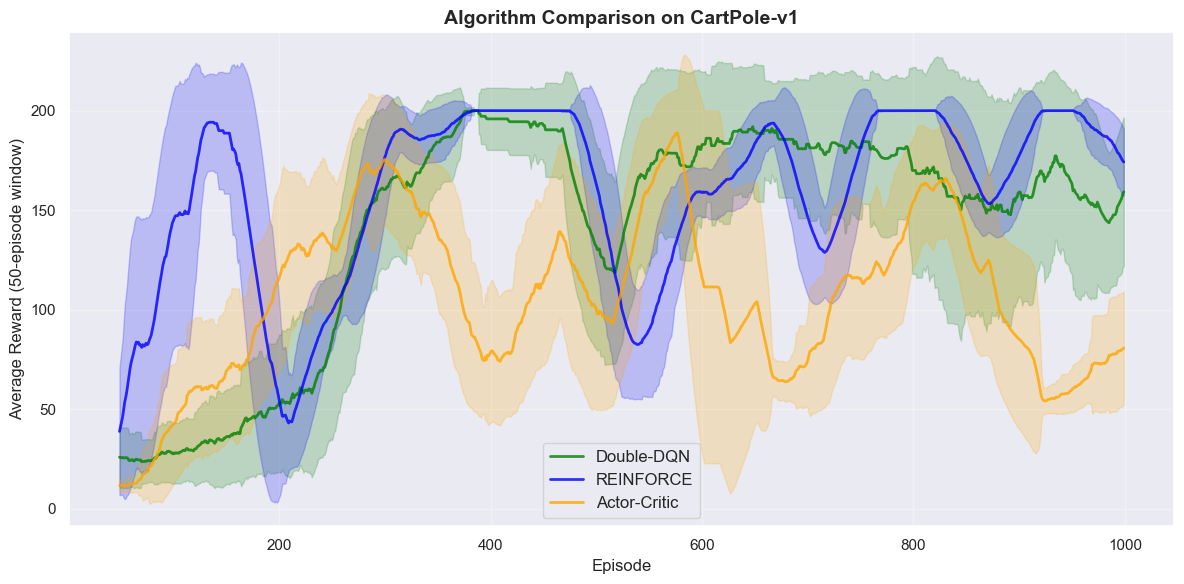


Final Performance on CartPole-v1 (last 100 episodes):
Double-DQN:    161.75 +/- 41.78
REINFORCE:     187.10 +/- 17.61
Actor-Critic:   70.02 +/- 24.02


In [28]:
# Plot CartPole results
plot_comparison(ddqn_rewards_cartpole, reinforce_rewards_cartpole, ac_rewards_cartpole, "CartPole-v1")

## Results: Acrobot Comparison

In [32]:
print(reinforce_rewards_acrobot)
print(ac_rewards_acrobot)

[-500.0, -471.0, -395.0, -306.0, -345.0, -303.0, -304.0, -500.0, -477.0, -451.0, -263.0, -379.0, -226.0, -309.0, -181.0, -159.0, -133.0, -146.0, -113.0, -92.0, -181.0, -132.0, -88.0, -106.0, -116.0, -86.0, -88.0, -83.0, -115.0, -80.0, -81.0, -151.0, -228.0, -108.0, -103.0, -200.0, -93.0, -129.0, -111.0, -107.0, -123.0, -94.0, -93.0, -111.0, -106.0, -136.0, -179.0, -188.0, -89.0, -121.0, -201.0, -127.0, -109.0, -92.0, -107.0, -178.0, -202.0, -93.0, -134.0, -118.0, -138.0, -101.0, -150.0, -100.0, -154.0, -181.0, -152.0, -144.0, -262.0, -132.0, -139.0, -106.0, -141.0, -107.0, -183.0, -141.0, -214.0, -210.0, -159.0, -167.0, -363.0, -297.0, -166.0, -327.0, -169.0, -337.0, -130.0, -337.0, -125.0, -141.0, -288.0, -215.0, -138.0, -359.0, -197.0, -452.0, -209.0, -280.0, -184.0, -335.0, -382.0, -339.0, -258.0, -352.0, -160.0, -173.0, -441.0, -271.0, -476.0, -500.0, -220.0, -500.0, -500.0, -420.0, -500.0, -331.0, -259.0, -310.0, -328.0, -174.0, -341.0, -435.0, -500.0, -500.0, -500.0, -500.0, -466

In [2]:
reinforce_rewards_acrobot =[-500.0, -471.0, -395.0, -306.0, -345.0, -303.0, -304.0, -500.0, -477.0, -451.0, -263.0, -379.0, -226.0, -309.0, -181.0, -159.0, -133.0, -146.0, -113.0, -92.0, -181.0, -132.0, -88.0, -106.0, -116.0, -86.0, -88.0, -83.0, -115.0, -80.0, -81.0, -151.0, -228.0, -108.0, -103.0, -200.0, -93.0, -129.0, -111.0, -107.0, -123.0, -94.0, -93.0, -111.0, -106.0, -136.0, -179.0, -188.0, -89.0, -121.0, -201.0, -127.0, -109.0, -92.0, -107.0, -178.0, -202.0, -93.0, -134.0, -118.0, -138.0, -101.0, -150.0, -100.0, -154.0, -181.0, -152.0, -144.0, -262.0, -132.0, -139.0, -106.0, -141.0, -107.0, -183.0, -141.0, -214.0, -210.0, -159.0, -167.0, -363.0, -297.0, -166.0, -327.0, -169.0, -337.0, -130.0, -337.0, -125.0, -141.0, -288.0, -215.0, -138.0, -359.0, -197.0, -452.0, -209.0, -280.0, -184.0, -335.0, -382.0, -339.0, -258.0, -352.0, -160.0, -173.0, -441.0, -271.0, -476.0, -500.0, -220.0, -500.0, -500.0, -420.0, -500.0, -331.0, -259.0, -310.0, -328.0, -174.0, -341.0, -435.0, -500.0, -500.0, -500.0, -500.0, -466.0, -500.0, -232.0, -428.0, -238.0, -482.0, -277.0, -300.0, -351.0, -500.0, -500.0, -232.0, -396.0, -193.0, -500.0, -500.0, -254.0, -213.0, -258.0, -155.0, -271.0, -135.0, -233.0, -206.0, -184.0, -331.0, -267.0, -152.0, -169.0, -163.0, -257.0, -217.0, -94.0, -213.0, -141.0, -271.0, -117.0, -392.0, -172.0, -461.0, -108.0, -150.0, -286.0, -163.0, -500.0, -308.0, -500.0, -123.0, -268.0, -180.0, -153.0, -356.0, -500.0, -142.0, -176.0, -155.0, -272.0, -204.0, -119.0, -143.0, -94.0, -106.0, -165.0, -215.0, -88.0, -136.0, -177.0, -105.0, -138.0, -147.0, -101.0, -179.0, -386.0, -234.0, -198.0, -121.0, -74.0, -121.0, -117.0, -128.0, -90.0, -189.0, -143.0, -89.0, -101.0, -125.0, -127.0, -86.0, -76.0, -72.0, -86.0, -104.0, -94.0, -65.0, -65.0, -86.0, -89.0, -94.0, -73.0, -95.0, -111.0, -85.0, -73.0, -100.0, -120.0, -80.0, -73.0, -95.0, -102.0, -95.0, -65.0, -73.0, -67.0, -74.0, -74.0, -187.0, -65.0, -103.0, -154.0, -109.0, -73.0, -78.0, -88.0, -74.0, -103.0, -72.0, -76.0, -132.0, -77.0, -96.0, -74.0, -74.0, -90.0, -73.0, -79.0, -76.0, -97.0, -120.0, -86.0, -95.0, -89.0, -96.0, -77.0, -95.0, -74.0, -77.0, -78.0, -92.0, -106.0, -97.0, -99.0, -85.0, -73.0, -191.0, -91.0, -76.0, -139.0, -98.0, -99.0, -179.0, -94.0, -71.0, -83.0, -72.0, -95.0, -90.0, -101.0, -78.0, -93.0, -72.0, -72.0, -85.0, -64.0, -100.0, -87.0, -73.0, -81.0, -87.0, -82.0, -74.0, -81.0, -73.0, -67.0, -99.0, -80.0, -89.0, -73.0, -94.0, -66.0, -77.0, -64.0, -83.0, -84.0, -181.0, -71.0, -77.0, -112.0, -97.0, -87.0, -64.0, -67.0, -103.0, -74.0, -167.0, -195.0, -148.0, -85.0, -90.0, -66.0, -75.0, -96.0, -66.0, -79.0, -101.0, -74.0, -145.0, -77.0, -73.0, -92.0, -154.0, -101.0, -62.0, -65.0, -82.0, -73.0, -114.0, -90.0, -72.0, -90.0, -79.0, -73.0, -68.0, -98.0, -117.0, -82.0, -86.0, -64.0, -81.0, -82.0, -76.0, -83.0, -89.0, -85.0, -99.0, -112.0, -75.0, -83.0, -125.0, -221.0, -146.0, -130.0, -165.0, -167.0, -203.0, -162.0, -189.0, -153.0, -163.0, -210.0, -155.0, -218.0, -151.0, -340.0, -160.0, -292.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0]

ddqn_rewards_acrobot=[-500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -308.0, -500.0, -500.0, -181.0, -343.0, -234.0, -192.0, -191.0, -217.0, -134.0, -241.0, -198.0, -246.0, -153.0, -147.0, -147.0, -147.0, -114.0, -150.0, -148.0, -126.0, -500.0, -116.0, -135.0, -108.0, -97.0, -120.0, -83.0, -89.0, -166.0, -110.0, -87.0, -93.0, -90.0, -87.0, -149.0, -105.0, -115.0, -126.0, -108.0, -91.0, -111.0, -107.0, -140.0, -62.0, -87.0, -93.0, -69.0, -82.0, -85.0, -96.0, -77.0, -122.0, -118.0, -102.0, -153.0, -92.0, -105.0, -113.0, -82.0, -106.0, -91.0, -102.0, -88.0, -78.0, -238.0, -148.0, -88.0, -80.0, -101.0, -102.0, -147.0, -83.0, -80.0, -92.0, -88.0, -106.0, -86.0, -102.0, -119.0, -136.0, -95.0, -84.0, -123.0, -101.0, -102.0, -79.0, -158.0, -77.0, -98.0, -84.0, -100.0, -131.0, -131.0, -122.0, -76.0, -110.0, -134.0, -84.0, -80.0, -77.0, -98.0, -91.0, -109.0, -96.0, -67.0, -98.0, -98.0, -112.0, -63.0, -88.0, -111.0, -104.0, -291.0, -104.0, -81.0, -98.0, -86.0, -98.0, -199.0, -81.0, -85.0, -92.0, -116.0, -91.0, -95.0, -74.0, -98.0, -75.0, -140.0, -77.0, -93.0, -95.0, -94.0, -77.0, -95.0, -118.0, -90.0, -114.0, -85.0, -102.0, -70.0, -91.0, -100.0, -89.0, -77.0, -102.0, -142.0, -91.0, -102.0, -123.0, -103.0, -108.0, -90.0, -116.0, -70.0, -93.0, -87.0, -124.0, -88.0, -101.0, -83.0, -95.0, -110.0, -88.0, -76.0, -109.0, -99.0, -104.0, -95.0, -149.0, -100.0, -118.0, -121.0, -109.0, -124.0, -87.0, -81.0, -84.0, -104.0, -90.0, -110.0, -224.0, -109.0, -71.0, -91.0, -116.0, -96.0, -85.0, -107.0, -92.0, -89.0, -82.0, -88.0, -117.0, -92.0, -110.0, -110.0, -77.0, -91.0, -101.0, -101.0, -80.0, -77.0, -90.0, -91.0, -98.0, -101.0, -76.0, -109.0, -89.0, -82.0, -119.0, -83.0, -83.0, -143.0, -91.0, -77.0, -73.0, -83.0, -97.0, -147.0, -93.0, -85.0, -85.0, -78.0, -67.0, -69.0, -71.0, -81.0, -106.0, -88.0, -82.0, -68.0, -110.0, -82.0, -109.0, -95.0, -184.0, -77.0, -97.0, -93.0, -99.0, -78.0, -118.0, -108.0, -86.0, -85.0, -98.0, -109.0, -88.0, -105.0, -98.0, -88.0, -109.0, -78.0, -94.0, -142.0, -115.0, -94.0, -121.0, -83.0, -110.0, -76.0, -76.0, -101.0, -121.0, -113.0, -84.0, -95.0, -127.0, -89.0, -93.0, -126.0, -103.0, -114.0, -88.0, -105.0, -85.0, -89.0, -108.0, -101.0, -95.0, -94.0, -90.0, -99.0, -82.0, -87.0, -87.0, -99.0, -97.0, -109.0, -106.0, -108.0, -123.0, -69.0, -96.0, -80.0, -86.0, -84.0, -94.0, -111.0, -94.0, -81.0, -86.0, -74.0, -88.0, -75.0, -97.0, -93.0, -89.0, -74.0, -91.0, -120.0, -94.0, -77.0, -107.0, -100.0, -96.0, -76.0, -91.0, -86.0, -110.0, -87.0, -115.0, -121.0, -87.0, -122.0, -68.0, -83.0, -80.0, -88.0, -79.0, -107.0, -79.0, -113.0, -85.0, -99.0, -77.0, -110.0, -98.0, -107.0, -96.0, -77.0, -90.0, -90.0, -76.0, -87.0, -83.0, -127.0, -96.0, -102.0, -109.0, -91.0, -87.0, -161.0, -91.0, -149.0, -95.0, -107.0, -82.0, -81.0, -94.0, -83.0, -103.0, -101.0, -96.0, -143.0, -80.0, -81.0, -76.0, -84.0, -109.0, -94.0, -90.0, -84.0, -83.0, -108.0, -213.0, -82.0, -101.0, -102.0, -86.0, -88.0, -73.0, -155.0, -88.0, -84.0, -112.0, -83.0, -93.0, -166.0, -100.0, -109.0, -70.0, -80.0, -65.0, -91.0, -75.0, -92.0, -72.0, -107.0, -124.0, -90.0, -125.0, -111.0, -81.0, -81.0, -84.0, -83.0, -63.0, -83.0, -83.0, -63.0, -133.0, -77.0, -82.0, -62.0, -105.0, -98.0, -93.0, -63.0, -96.0, -75.0, -85.0, -91.0, -102.0, -87.0, -87.0, -75.0, -104.0, -81.0, -102.0, -81.0, -90.0, -96.0, -127.0, -95.0, -98.0, -108.0, -80.0, -97.0, -106.0, -115.0, -91.0, -86.0, -90.0, -118.0, -83.0, -83.0, -116.0, -87.0, -81.0, -90.0, -107.0, -80.0, -97.0, -91.0, -92.0, -83.0, -74.0, -93.0, -99.0, -90.0, -91.0, -89.0, -88.0, -92.0, -109.0, -105.0, -181.0, -95.0, -85.0, -86.0, -101.0, -81.0, -87.0, -64.0, -85.0, -108.0, -86.0, -108.0, -132.0, -108.0, -102.0, -63.0, -82.0, -113.0, -90.0, -82.0, -101.0, -84.0, -100.0, -107.0, -77.0, -112.0, -111.0, -139.0, -152.0, -76.0, -82.0, -96.0, -91.0, -101.0, -118.0, -121.0, -87.0, -100.0, -98.0, -91.0, -86.0, -62.0, -123.0, -97.0, -104.0, -98.0, -86.0, -102.0, -153.0, -119.0, -77.0, -93.0, -109.0, -88.0, -132.0, -133.0, -93.0, -121.0, -85.0, -88.0, -87.0, -78.0, -84.0, -120.0, -63.0, -85.0, -112.0, -116.0, -107.0, -77.0, -83.0, -89.0, -75.0, -94.0, -82.0, -80.0, -86.0, -114.0, -91.0, -104.0, -92.0, -68.0, -84.0, -84.0, -81.0, -72.0, -74.0, -62.0, -118.0, -76.0, -77.0, -121.0, -86.0, -85.0, -161.0, -98.0, -108.0, -92.0, -81.0, -82.0, -69.0, -123.0, -100.0, -104.0, -69.0, -96.0, -72.0, -88.0, -98.0, -76.0, -98.0, -77.0, -136.0, -115.0, -113.0, -76.0, -113.0, -70.0, -106.0, -95.0, -99.0, -116.0, -97.0, -107.0, -92.0, -118.0, -94.0, -91.0, -85.0, -112.0, -85.0, -76.0, -126.0, -114.0, -62.0, -116.0, -70.0, -177.0, -69.0, -77.0, -87.0, -117.0, -131.0, -77.0, -85.0, -83.0, -94.0, -74.0, -103.0, -69.0, -120.0, -84.0, -90.0, -86.0, -143.0, -76.0, -85.0, -93.0, -96.0, -70.0, -63.0, -95.0, -97.0, -70.0, -93.0, -82.0, -107.0, -96.0, -84.0, -97.0, -104.0, -68.0, -103.0, -119.0, -111.0, -64.0, -121.0, -96.0, -92.0, -101.0, -86.0, -103.0, -75.0, -84.0, -135.0, -83.0, -90.0, -70.0, -96.0, -94.0, -77.0, -77.0, -82.0, -76.0, -79.0, -102.0, -67.0, -76.0, -83.0, -108.0, -114.0, -80.0, -118.0, -100.0, -103.0, -100.0, -111.0, -105.0, -90.0, -72.0, -95.0, -86.0, -103.0, -83.0, -90.0, -108.0, -118.0, -84.0, -68.0, -115.0, -73.0, -95.0, -101.0, -75.0, -95.0, -104.0, -112.0, -86.0, -91.0, -96.0, -98.0, -78.0, -106.0, -108.0, -91.0, -88.0, -130.0, -110.0, -112.0, -112.0, -144.0, -115.0, -83.0, -75.0, -78.0, -136.0, -103.0, -116.0, -101.0, -90.0, -72.0, -64.0, -89.0, -129.0, -90.0, -88.0, -101.0, -100.0, -83.0, -87.0, -85.0, -84.0, -83.0, -92.0, -92.0, -68.0, -80.0, -81.0, -83.0, -72.0, -84.0, -76.0, -85.0, -121.0, -69.0, -77.0, -92.0, -116.0, -119.0, -92.0, -88.0, -86.0, -83.0, -62.0, -108.0, -93.0, -91.0, -114.0, -111.0, -76.0, -90.0, -70.0, -101.0, -92.0, -152.0, -75.0, -74.0, -82.0, -121.0, -62.0, -92.0, -76.0, -89.0, -148.0, -90.0, -140.0, -81.0, -127.0, -76.0, -70.0, -87.0, -63.0, -130.0, -85.0, -88.0, -131.0, -73.0, -88.0, -83.0, -98.0, -110.0, -83.0, -85.0, -78.0, -82.0, -64.0, -99.0, -116.0, -103.0, -132.0, -85.0, -78.0, -120.0, -75.0, -68.0, -75.0, -111.0, -77.0, -106.0, -105.0, -61.0, -84.0, -72.0, -185.0, -108.0, -86.0, -76.0, -78.0, -68.0, -82.0, -82.0, -91.0, -68.0, -103.0, -85.0, -65.0, -83.0, -89.0, -88.0, -91.0, -84.0, -122.0, -118.0, -84.0, -84.0, -83.0, -105.0, -76.0, -90.0, -103.0, -123.0, -89.0, -81.0, -76.0, -83.0, -77.0, -88.0, -166.0, -107.0, -76.0, -82.0, -95.0, -87.0, -143.0, -83.0, -112.0, -100.0, -82.0, -62.0, -75.0, -77.0, -84.0, -84.0, -75.0, -72.0, -77.0, -75.0, -80.0, -63.0, -85.0, -106.0, -74.0, -74.0, -83.0, -81.0, -75.0, -76.0, -81.0, -77.0, -81.0, -85.0, -117.0, -142.0, -75.0, -109.0, -85.0, -85.0, -75.0, -85.0, -72.0, -106.0, -69.0, -71.0, -106.0, -145.0, -95.0, -107.0, -86.0, -96.0, -106.0, -76.0, -79.0, -62.0, -82.0, -78.0, -73.0, -88.0, -113.0, -119.0, -106.0, -64.0, -91.0, -70.0, -108.0, -79.0, -76.0, -99.0, -78.0, -110.0, -76.0, -81.0, -78.0, -91.0, -109.0, -75.0, -106.0, -126.0, -135.0, -84.0, -71.0, -91.0, -97.0, -78.0, -105.0, -227.0, -84.0, -115.0, -69.0, -77.0, -103.0, -92.0, -81.0, -82.0, -69.0, -132.0, -78.0, -86.0, -63.0, -74.0, -93.0, -99.0, -110.0, -79.0, -100.0, -84.0, -104.0, -120.0, -136.0, -106.0, -135.0, -75.0, -74.0, -90.0, -88.0, -75.0, -78.0, -69.0, -76.0, -82.0, -74.0, -125.0, -81.0, -88.0, -88.0, -83.0, -111.0, -89.0, -111.0, -94.0, -205.0, -67.0, -82.0, -83.0, -131.0, -89.0, -80.0, -81.0, -107.0, -96.0, -87.0, -89.0]

ac_rewards_acrobot = [-221.0, -99.0, -205.0, -98.0, -86.0, -106.0, -94.0, -109.0, -106.0, -132.0, -114.0, -92.0, -79.0, -81.0, -95.0, -109.0, -97.0, -170.0, -192.0, -268.0, -104.0, -159.0, -143.0, -82.0, -89.0, -122.0, -102.0, -93.0, -108.0, -79.0, -80.0, -89.0, -74.0, -91.0, -91.0, -102.0, -97.0, -73.0, -76.0, -125.0, -77.0, -87.0, -145.0, -232.0, -156.0, -109.0, -115.0, -124.0, -113.0, -86.0, -110.0, -79.0, -99.0, -89.0, -82.0, -92.0, -75.0, -117.0, -96.0, -74.0, -73.0, -91.0, -77.0, -73.0, -86.0, -97.0, -99.0, -80.0, -91.0, -84.0, -84.0, -97.0, -86.0, -96.0, -78.0, -73.0, -94.0, -108.0, -64.0, -86.0, -84.0, -157.0, -84.0, -62.0, -89.0, -64.0, -116.0, -120.0, -92.0, -78.0, -65.0, -72.0, -65.0, -64.0, -112.0, -102.0, -102.0, -89.0, -165.0, -93.0, -95.0, -78.0, -105.0, -80.0, -84.0, -274.0, -94.0, -99.0, -116.0, -64.0, -105.0, -125.0, -96.0, -90.0, -84.0, -90.0, -77.0, -81.0, -86.0, -73.0, -83.0, -64.0, -71.0, -79.0, -94.0, -79.0, -72.0, -176.0, -89.0, -80.0, -96.0, -67.0, -90.0, -74.0, -103.0, -80.0, -85.0, -83.0, -89.0, -63.0, -84.0, -90.0, -72.0, -72.0, -78.0, -81.0, -75.0, -83.0, -66.0, -71.0, -147.0, -65.0, -93.0, -75.0, -75.0, -89.0, -106.0, -74.0, -78.0, -77.0, -74.0, -73.0, -92.0, -73.0, -69.0, -76.0, -103.0, -83.0, -71.0, -78.0, -72.0, -101.0, -94.0, -78.0, -71.0, -89.0, -71.0, -83.0, -83.0, -81.0, -78.0, -276.0, -87.0, -90.0, -74.0, -86.0, -79.0, -78.0, -92.0, -95.0, -96.0, -84.0, -77.0, -100.0, -90.0, -78.0, -84.0, -74.0, -84.0, -80.0, -72.0, -79.0, -74.0, -72.0, -65.0, -82.0, -76.0, -73.0, -90.0, -71.0, -87.0, -91.0, -93.0, -114.0, -72.0, -74.0, -75.0, -85.0, -72.0, -86.0, -86.0, -80.0, -79.0, -64.0, -112.0, -74.0, -87.0, -98.0, -65.0, -128.0, -76.0, -95.0, -81.0, -95.0, -266.0, -77.0, -80.0, -74.0, -79.0, -81.0, -92.0, -73.0, -75.0, -91.0, -65.0, -98.0, -96.0, -98.0, -116.0, -90.0, -72.0, -173.0, -72.0, -77.0, -89.0, -84.0, -98.0, -97.0, -76.0, -64.0, -104.0, -70.0, -91.0, -71.0, -93.0, -122.0, -73.0, -87.0, -91.0, -81.0, -92.0, -101.0, -201.0, -78.0, -71.0, -77.0, -71.0, -78.0, -78.0, -83.0, -77.0, -86.0, -70.0, -87.0, -86.0, -72.0, -91.0, -78.0, -77.0, -76.0, -84.0, -77.0, -64.0, -78.0, -79.0, -500.0, -78.0, -84.0, -94.0, -71.0, -78.0, -73.0, -69.0, -77.0, -68.0, -78.0, -72.0, -84.0, -76.0, -69.0, -77.0, -69.0, -77.0, -68.0, -85.0, -83.0, -68.0, -78.0, -79.0, -85.0, -85.0, -64.0, -87.0, -63.0, -120.0, -92.0, -94.0, -82.0, -72.0, -88.0, -90.0, -119.0, -86.0, -72.0, -178.0, -95.0, -71.0, -73.0, -64.0, -91.0, -80.0, -76.0, -80.0, -138.0, -77.0, -72.0, -76.0, -76.0, -65.0, -77.0, -91.0, -106.0, -77.0, -76.0, -77.0, -79.0, -86.0, -73.0, -72.0, -87.0, -88.0, -500.0, -85.0, -85.0, -74.0, -85.0, -81.0, -78.0, -93.0, -97.0, -88.0, -83.0, -85.0, -78.0, -76.0, -65.0, -70.0, -152.0, -96.0, -91.0, -97.0, -211.0, -98.0, -99.0, -105.0, -90.0, -74.0, -173.0, -92.0, -110.0, -76.0, -72.0, -95.0, -122.0, -95.0, -73.0, -77.0, -93.0, -103.0, -109.0, -119.0, -71.0, -77.0, -100.0, -142.0, -88.0, -81.0, -74.0, -112.0, -76.0, -72.0, -87.0, -218.0, -88.0, -72.0, -73.0, -90.0, -105.0, -121.0, -90.0, -77.0, -79.0, -90.0, -64.0, -91.0, -72.0, -91.0, -64.0, -78.0, -84.0, -108.0, -64.0, -77.0, -76.0, -87.0, -92.0, -95.0, -73.0, -78.0, -72.0, -78.0, -90.0, -77.0, -105.0, -73.0, -71.0, -72.0, -75.0, -78.0, -98.0, -72.0, -77.0, -85.0, -73.0, -78.0, -112.0, -91.0, -73.0, -89.0, -112.0, -80.0, -64.0, -89.0, -79.0, -79.0, -78.0, -90.0, -87.0, -84.0, -77.0, -93.0, -77.0, -77.0, -135.0, -81.0, -88.0, -91.0, -77.0, -79.0, -78.0, -63.0, -64.0, -87.0, -78.0, -84.0, -65.0, -73.0, -87.0, -82.0, -91.0, -71.0, -105.0, -79.0, -89.0, -64.0, -71.0, -74.0, -157.0, -73.0, -81.0, -93.0, -77.0, -78.0, -161.0, -73.0, -72.0, -72.0, -72.0, -72.0, -72.0, -85.0, -94.0, -82.0, -86.0, -80.0, -78.0, -90.0, -83.0, -80.0, -72.0, -64.0, -96.0, -73.0, -91.0, -80.0, -73.0, -84.0, -72.0, -79.0, -77.0, -77.0, -92.0, -76.0, -76.0, -76.0, -78.0, -76.0, -72.0, -84.0, -91.0, -106.0, -78.0, -85.0, -78.0, -71.0, -74.0, -83.0, -71.0, -71.0, -73.0, -89.0, -85.0, -86.0, -78.0, -72.0, -84.0, -93.0, -79.0, -71.0, -86.0, -85.0, -72.0, -86.0, -70.0, -115.0, -78.0, -73.0, -77.0, -76.0, -81.0, -63.0, -77.0, -65.0, -72.0, -75.0, -95.0, -78.0, -73.0, -86.0, -78.0, -83.0, -78.0, -82.0, -63.0, -79.0, -76.0, -69.0, -87.0, -83.0, -69.0, -86.0, -70.0, -73.0, -93.0, -95.0, -78.0, -88.0, -89.0, -159.0, -71.0, -77.0, -82.0, -85.0, -84.0, -94.0, -85.0, -83.0, -64.0, -73.0, -78.0, -77.0, -80.0, -64.0, -76.0, -72.0, -87.0, -79.0, -79.0, -79.0, -76.0, -77.0, -72.0, -74.0, -72.0, -72.0, -72.0, -73.0, -63.0, -77.0, -138.0, -77.0, -85.0, -71.0, -79.0, -80.0, -82.0, -77.0, -80.0, -77.0, -77.0, -87.0, -74.0, -154.0, -64.0, -98.0, -93.0, -63.0, -70.0, -77.0, -71.0, -73.0, -62.0, -84.0, -89.0, -100.0, -80.0, -79.0, -72.0, -80.0, -81.0, -126.0, -85.0, -64.0, -72.0, -73.0, -89.0, -121.0, -94.0, -94.0, -90.0, -77.0, -83.0, -90.0, -92.0, -88.0, -72.0, -65.0, -72.0, -82.0, -73.0, -73.0, -72.0, -65.0, -70.0, -80.0, -72.0, -71.0, -83.0, -86.0, -77.0, -90.0, -87.0, -89.0, -86.0, -88.0, -79.0, -91.0, -63.0, -70.0, -84.0, -75.0, -247.0, -81.0, -77.0, -78.0, -86.0, -64.0, -72.0, -87.0, -79.0, -85.0, -104.0, -85.0, -86.0, -76.0, -82.0, -85.0, -64.0, -76.0, -88.0, -73.0, -89.0, -78.0, -78.0, -77.0, -103.0, -92.0, -72.0, -73.0, -65.0, -92.0, -82.0, -80.0, -72.0, -93.0, -77.0, -73.0, -79.0, -84.0, -69.0, -106.0, -77.0, -88.0, -78.0, -79.0, -79.0, -83.0, -81.0, -208.0, -72.0, -100.0, -81.0, -78.0, -85.0, -99.0, -80.0, -113.0, -111.0, -86.0, -83.0, -86.0, -85.0, -78.0, -72.0, -82.0, -73.0, -80.0, -91.0, -84.0, -91.0, -85.0, -81.0, -87.0, -79.0, -88.0, -73.0, -76.0, -78.0, -79.0, -89.0, -90.0, -91.0, -82.0, -79.0, -168.0, -89.0, -79.0, -72.0, -73.0, -93.0, -85.0, -104.0, -63.0, -72.0, -81.0, -82.0, -112.0, -87.0, -70.0, -84.0, -72.0, -133.0, -85.0, -76.0, -78.0, -86.0, -78.0, -103.0, -110.0, -64.0, -85.0, -64.0, -94.0, -80.0, -97.0, -165.0, -102.0, -87.0, -71.0, -89.0, -72.0, -71.0, -99.0, -109.0, -71.0, -73.0, -109.0, -85.0, -93.0, -91.0, -84.0, -91.0, -90.0, -84.0, -85.0, -78.0, -164.0, -81.0, -83.0, -85.0, -106.0, -77.0, -69.0, -96.0, -79.0, -90.0, -79.0, -86.0, -84.0, -77.0, -95.0, -76.0, -90.0, -86.0, -73.0, -77.0, -64.0, -95.0, -83.0, -72.0, -72.0, -90.0, -72.0, -76.0, -76.0, -73.0, -79.0, -81.0, -97.0, -77.0, -85.0, -94.0, -72.0, -71.0, -73.0, -109.0, -78.0, -72.0, -73.0, -93.0, -74.0, -93.0, -93.0, -84.0, -79.0, -78.0, -76.0, -71.0, -73.0, -76.0, -106.0, -91.0, -86.0, -81.0, -71.0, -84.0, -89.0, -76.0, -77.0, -87.0, -63.0, -85.0, -76.0, -88.0, -82.0, -82.0, -72.0, -83.0, -130.0, -84.0, -85.0, -80.0, -78.0, -72.0, -74.0, -79.0, -93.0, -95.0, -79.0, -65.0, -86.0, -77.0, -93.0, -76.0, -79.0, -81.0, -137.0, -194.0, -76.0, -79.0, -79.0, -78.0, -90.0, -86.0, -72.0, -76.0, -73.0, -76.0, -85.0, -71.0, -83.0, -97.0, -72.0, -77.0, -72.0, -73.0, -71.0, -98.0, -78.0, -71.0, -72.0, -85.0, -75.0, -70.0, -88.0, -87.0, -77.0, -76.0, -81.0, -71.0, -88.0, -317.0, -92.0, -100.0, -88.0, -79.0, -69.0, -94.0, -89.0, -89.0, -86.0, -84.0, -77.0, -88.0, -71.0, -86.0, -88.0, -77.0, -154.0, -79.0, -86.0, -88.0, -86.0, -121.0, -80.0, -73.0, -74.0, -78.0, -69.0, -72.0, -86.0, -98.0, -79.0, -79.0, -85.0, -72.0, -79.0, -77.0, -73.0, -95.0]

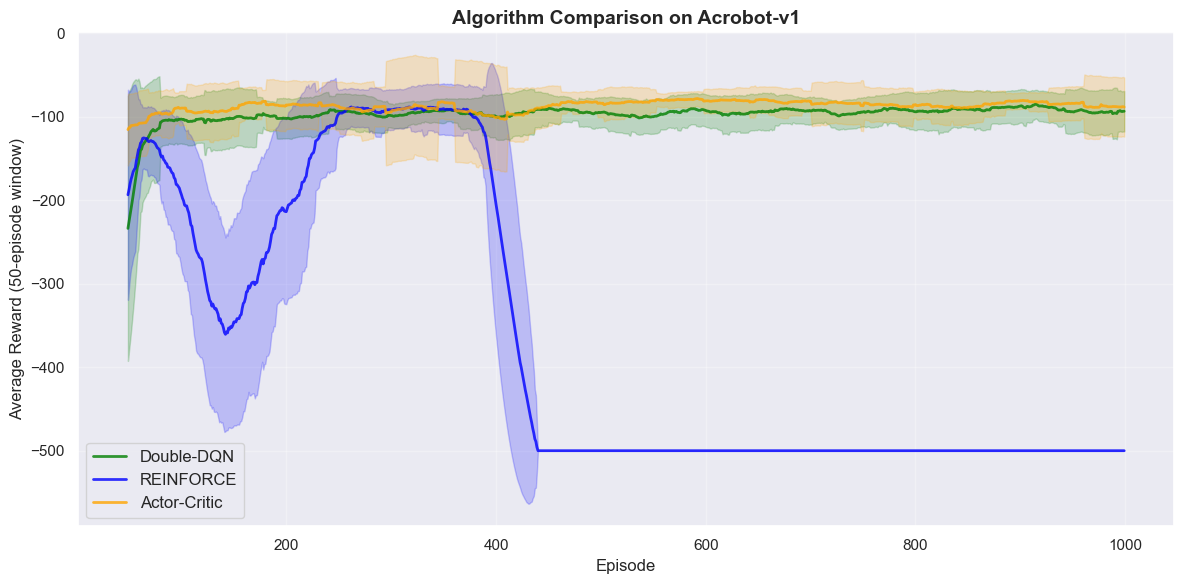


Final Performance on Acrobot-v1 (last 100 episodes):
Double-DQN:    -93.81 +/- 25.36
REINFORCE:    -500.00 +/- 0.00
Actor-Critic:  -86.28 +/- 28.99


In [5]:
# Plot Acrobot results
plot_comparison(ddqn_rewards_acrobot, reinforce_rewards_acrobot, ac_rewards_acrobot, "Acrobot-v1")

## Analysis Questions

Answer these questions based on your experimental results:

### CartPole Analysis

**Q1**: Which method converges fastest on CartPole? How many episodes approximately?

**Your answer**: REINFORCE

**Q2**: Which method shows lowest variance (most stable learning)?

**Your answer**: Actor-Critic

**Q3**: Compare final performance of all three methods. Which achieves highest average reward?

**Your answer**: reinforce

### Acrobot Analysis

**Q4**: Which method works best on Acrobot (harder environment)?

**Your answer**: Actor-Critic

**Q5**: Is Actor-Critic's advantage more pronounced on Acrobot than CartPole? Why?

**Your answer**: Yes, The reward is -1 for each step and REINFORCE waits for the end of the episode (Monte-Carlo)

### Comparative Analysis

**Q6**: How do value-based (DDQN) and policy-based (REINFORCE, Actor-Critic) methods compare overall?

**Your answer**: DDQN learns Q-values, derives an implicit policy, descrete space. Policy gradient methods optimize the policy, good for continuous spaces, but cant reuse old data. 

**Q7**: Explain why Actor-Critic outperforms REINFORCE in terms of bias-variance trade-off.

**Your answer**: In my examples, it outperforms on harder environment - Acrobot. REINFORCE uses Monte-Carlo approach that waits until the end of the episode and one unlucky trajectory can modify the gradient. Actor-Critic uses TD error, has a small bias but a lower variance, leading to smooth learning and faster convergence. In Acrobs, there are many steps and high penalities, so the results for REINFORCE plateau. 

**Q8**: When would you choose policy gradient methods over value-based methods in practice?

**Your answer**: When continuous space of actions (not tabular data) or when the policy is simpler than the value (simpler to learn go left than estimate the value).

## Conclusion

### Key Takeaways

1. **Policy Gradient Methods** optimize policies directly
   - REINFORCE: Simple but high variance
   - Actor-Critic: Lower variance through value function

2. **Comparison Insights**:
   - Value-based (DDQN): Good for discrete actions
   - Policy-based: Better for stochastic policies, continuous actions
   - Actor-Critic: Best of both worlds

3. **Foundations for Advanced RL**:
   - A3C/A2C: Parallel Actor-Critic
   - PPO: Actor-Critic + Trust regions
   - SAC: Actor-Critic + Maximum entropy
   - DDPG/TD3: Actor-Critic for continuous actions